# Crystal plasticity formulations

There are two common ways to formulate crystal plasticity kinematics:

1. **Approximated** — split the kinematics into two coupled rate equations, one
   for the elastic stretch and one for the crystal *orientation*, integrated in
   *additive* rate form. This is the small-elastic-strain approximation of the
   multiplicative decomposition.
2. **Exact** — integrate the plastic deformation gradient $F_p$ directly from the
   plastic spatial velocity gradient $l_p$, using the full $F = F_e F_p$
   multiplicative decomposition with no kinematic approximation.

Both rest on the multiplicative decomposition $F = F_e F_p$. The first form is
cheaper and integrates additively, but assumes the elastic strains are small; the
second makes no such assumption.

A NEML2 crystal model can be written either way while reusing the *same*
constitutive pieces — the slip rule, the hardening law, the crystal geometry.
Only a few specialized sub-models differ. Here we run equivalent approximated and
exact models through the same rolling history (to 50% rolling strain),
reconstruct the deformed textures, and compare. Because the elastic strains stay
small here, the approximation should be excellent and the two should agree.

The two models are defined in input files alongside this notebook,
[`crystal_approximated.i`](crystal_approximated.i) and
[`crystal_exact.i`](crystal_exact.i). Each defines just the `NonlinearSystem` —
the load history and the time integration live here on the Python side, driven by
[pyzag](https://github.com/Argonne-National-Laboratory/pyzag). For more on the
pyzag driver see the
[pyzag tutorial](#tutorials-optimization-pyzag).

```{note}
This is a heavier example (500 crystals, 2500 time steps) and is committed
pre-executed; it runs on the GPU when one is available.
```

## Setup

This example simulates rolling in an FCC material. `rate` is the strain rate,
`total_rolling_strain` the reduction strain, `ntime` the number of time steps,
`ncrystal` the number of random initial orientations, and `nchunk` the pyzag
vectorized time-integration chunk size.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torch

import neml2
from neml2.types import MRP, R2, SR2, WR2, Scalar, compose, r2_from_sr2, r2_from_wr2
from neml2.pyzag import NEML2PyzagModel
import neml2.texture as texture
from pyzag import nonlinear, chunktime

torch.manual_seed(0)
torch.set_default_dtype(torch.double)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

nchunk = 10
ncrystal = 500

rate = 0.0001
total_rolling_strain = 0.5
ntime = 2500
end_time = total_rolling_strain / rate

Using device: cpu


/home/tranh/miniconda3/envs/neml2_pyzag_ci/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


### The deformation history

Rolling is an isochoric stretch: extension in one transverse direction balanced
by contraction in the rolling direction, with no spin. We build the deformation
rate (an `SR2`) and the vorticity (a `WR2`); the exact model additionally needs
the deformation gradient $F$, which we obtain by integrating the spatial velocity
gradient $l = \dot\varepsilon + w$ with the exponential map.

The 500 initial orientations are sampled uniformly on $SO(3)$ with `MRP.rand`.

In [2]:
# Deformation rate (symmetric) and vorticity (skew), as typed batched tensors
# over (ntime, ncrystal). Rolling: +rate along y, -rate along z, no spin.
deformation_rate = torch.zeros((ntime, ncrystal, 6), device=device)
deformation_rate[:, :, 1] = rate
deformation_rate[:, :, 2] = -rate
deformation_rate = SR2(deformation_rate)
vorticity = WR2(torch.zeros((ntime, ncrystal, 3), device=device))
times = torch.linspace(0, end_time, ntime, device=device).unsqueeze(-1).expand(ntime, ncrystal)

# Uniformly random initial orientations (modified Rodrigues parameters).
initial_orientations = MRP.rand(ncrystal, device=device)

In [3]:
# The exact model is driven by the deformation gradient F. Build it from the
# spatial velocity gradient l = sym(deformation_rate) + skew(vorticity) using the
# typed SR2/WR2 -> R2 reconstructions, then integrate with the matrix exponential.
spatial_velocity_gradient = r2_from_sr2(deformation_rate).data + r2_from_wr2(vorticity).data
F = torch.zeros_like(spatial_velocity_gradient)
F[0] = torch.eye(3, device=device)
dt = torch.diff(times, dim=0)
Finc = torch.linalg.matrix_exp(spatial_velocity_gradient[:-1] * dt[..., None, None])
for i in range(1, ntime):
    F[i] = Finc[i - 1] @ F[i - 1]
F = R2(F)

### pyzag helpers

pyzag integrates a NEML2 `NonlinearSystem` through the load history. The
`NEML2PyzagModel` adapts the system to pyzag's solver and bridges the typed
NEML2 surface and pyzag's flat tensors:

- `factory.assemble_forces` packs a `{name: tensor}` dict (each force tensor
  shaped `(ntime, ncrystal, *base)`) into pyzag's flat force layout.
- `factory.assemble_state` packs a `{name: tensor}` dict of initial conditions
  (each shaped `(ncrystal, *base)`, one entry per state variable) into the flat
  initial state.
- `extract` slices a named variable back out of the integrated `(..., nstate)`
  history.

`make_solver` builds the chunked Newton-Raphson solver.

In [4]:
def extract(pmodel, history, name):
    offset = 0
    for var in pmodel.slayout.vars():
        size = pmodel.slayout.var_size(var)
        if var == name:
            return history[..., offset : offset + size]
        offset += size
    raise KeyError(name)


def make_solver(pmodel):
    return nonlinear.RecursiveNonlinearEquationSolver(
        pmodel,
        step_generator=nonlinear.StepGenerator(nchunk),
        predictor=nonlinear.PreviousStepsPredictor(),
        nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=1.0e-6, atol=1.0e-8),
    )

## Approximated formulation

The approximated model carries the elastic strain, the slip hardening, and the
crystal orientation as unknowns, integrating coupled rate equations for each in
additive form. The orientation is seeded with the random initial texture; the
deformation rate and vorticity drive the model.

In [5]:
nmodel_approx = neml2.load_nonlinear_system("crystal_approximated.i", "eq_sys")
nmodel_approx.model.to(device=device)
pmodel_approx = NEML2PyzagModel(nmodel_approx)

forces_approx = pmodel_approx.assemble_forces(
    {"deformation_rate": deformation_rate.data, "vorticity": vorticity.data, "t": times}
)
state0_approx = pmodel_approx.assemble_state(
    {
        "elastic_strain": torch.zeros(ncrystal, 6, device=device),
        "slip_hardening": torch.zeros(ncrystal, device=device),
        "orientation": initial_orientations.data,
    }
)

with torch.no_grad():
    history_approx = nonlinear.solve_adjoint(
        make_solver(pmodel_approx), state0_approx, len(forces_approx), forces_approx
    )

orientations_approx = MRP(extract(pmodel_approx, history_approx, "orientation")[-1])
print("approximated final orientations:", tuple(orientations_approx.data.shape))

/home/tranh/.claude_tmp/ipykernel_1759050/2376264195.py:12: UserWarning: pyzag lowered torch._functorch.config.donated_buffer's default to False process-wide. AOTAutograd 'donated buffers' (torch>=2.12) are incompatible with pyzag's retain_graph=True adjoint over torch.compile'd models, which otherwise raises 'compiled with non-empty donated buffers'. To keep donated buffers enabled, restore torch._functorch.config._config['donated_buffer'].default = True -- compiled models differentiated through the adjoint will then error.
  return nonlinear.RecursiveNonlinearEquationSolver(


approximated final orientations: (500, 3)


We reconstruct a continuous orientation distribution function (ODF) from the
discrete final orientations with a kernel density estimate. The
de la Vallee Poussin kernel half-width is fixed (rather than cross-validated) so
the two formulations are compared on equal footing.

In [6]:
odf_approx = texture.KDEODF(
    orientations_approx, texture.DeLaValleePoussinKernel(torch.tensor(0.2, device=device))
)
odf_approx.kernel.h = torch.tensor(0.23, device=device)

## Exact formulation

The exact model carries the slip hardening and the plastic deformation gradient
$F_p$ as unknowns; the orientation enters as a fixed reference force `r`. $F_p$ is
seeded to the identity. The model is driven by the deformation gradient $F$.

In [7]:
nmodel_exact = neml2.load_nonlinear_system("crystal_exact.i", "eq_sys")
nmodel_exact.model.to(device=device)
pmodel_exact = NEML2PyzagModel(nmodel_exact)

r_force = MRP(initial_orientations.data.unsqueeze(0).expand(ntime, ncrystal, 3).contiguous())
forces_exact = pmodel_exact.assemble_forces({"r": r_force.data, "F": F.data, "t": times})
eye = torch.eye(3, device=device).expand(ncrystal, 3, 3).contiguous()
state0_exact = pmodel_exact.assemble_state(
    {"tauc": torch.zeros(ncrystal, device=device), "Fp": eye}
)

with torch.no_grad():
    history_exact = nonlinear.solve_adjoint(
        make_solver(pmodel_exact), state0_exact, len(forces_exact), forces_exact
    )
print("exact state history:", tuple(history_exact.shape))

exact state history: (2500, 500, 10)


Extracting the orientation from the exact model takes some doing. We recover $F_p$
from the final state, form $F_e = F F_p^{-1}$, take the rotation $R_e$ from a polar
decomposition of $F_e$, convert it to an MRP with `MRP.from_matrix`, and finally
compose it with the initial orientation to get the deformed texture.

In [8]:
def lattice_rotation(Fp_flat, F_now):
    # Rotation (as MRP) from the elastic part of F, via polar decomposition of Fe.
    Fp = Fp_flat.reshape(Fp_flat.shape[:-1] + (3, 3))
    Fe = F_now @ torch.linalg.inv(Fp)
    U, _, Vh = torch.linalg.svd(Fe)
    return MRP.from_matrix(R2(U @ Vh))


Fp_final = extract(pmodel_exact, history_exact, "Fp")[-1]
Re = lattice_rotation(Fp_final, F.data[-1])
orientations_exact = compose(Re, initial_orientations)
print("exact final orientations:", tuple(orientations_exact.data.shape))

odf_exact = texture.KDEODF(
    orientations_exact, texture.DeLaValleePoussinKernel(torch.tensor(0.2, device=device))
)
odf_exact.kernel.h = torch.tensor(0.23, device=device)

exact final orientations: (500, 3)


## Compare the textures

The reconstructed ODFs give continuous $\{111\}$ pole figures for each
formulation. With cubic crystal symmetry (`"432"`) the two should look the same.

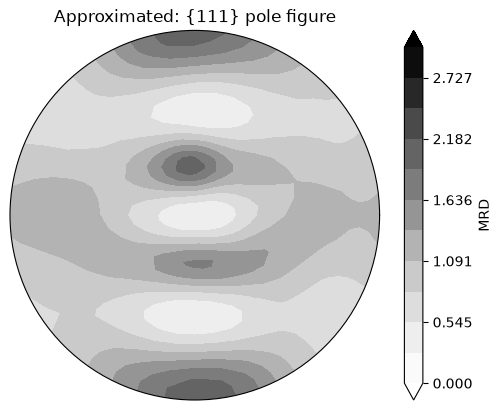

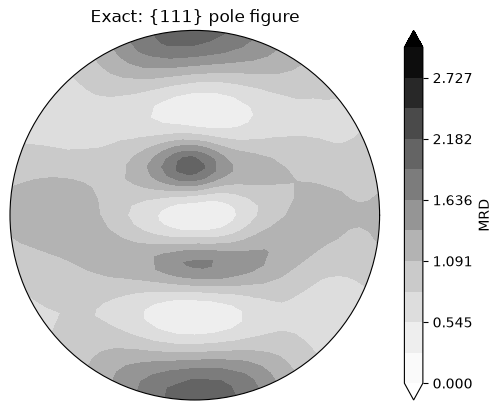

In [9]:
pole = torch.tensor([1.0, 1.0, 1.0], device=device)
for name, odf in [("Approximated", odf_approx), ("Exact", odf_exact)]:
    texture.pretty_plot_pole_figure_odf(
        odf, pole, crystal_symmetry="432", limits=(0.0, 3.0), ncontour=12
    )
    plt.title(f"{name}: {{111}} pole figure")
    plt.show()

## Compare the elastic strains

Finally we compare the elastic strain histories. For the approximated model the
elastic strain is a state variable; for the exact model we recover it from
$F_e = F F_p^{-1}$ over the whole history via the Green-Lagrange-like measure
$E = \tfrac12 (U_e^\top U_e - I)$ of the elastic stretch $U_e$.

The per-crystal histories differ slightly between the two measures, but their
averages agree — confirming the additive approximation is excellent at these
(small) elastic strains.

In [10]:
# Approximated: elastic strain is a state variable (SR2, Mandel order).
elastic_strain_approx = SR2(extract(pmodel_approx, history_approx, "elastic_strain"))

# Exact: recover the elastic stretch over the whole history.
Fp_hist = extract(pmodel_exact, history_exact, "Fp").reshape(ntime, ncrystal, 3, 3)
Fe_hist = F.data @ torch.linalg.inv(Fp_hist)
U_hist, S_hist, Vh_hist = torch.linalg.svd(Fe_hist)
Ue_hist = Vh_hist.transpose(-2, -1) @ torch.diag_embed(S_hist) @ Vh_hist
E_exact = 0.5 * (Ue_hist.transpose(-2, -1) @ Ue_hist - torch.eye(3, device=device))

t_axis = times[:, 0].cpu()

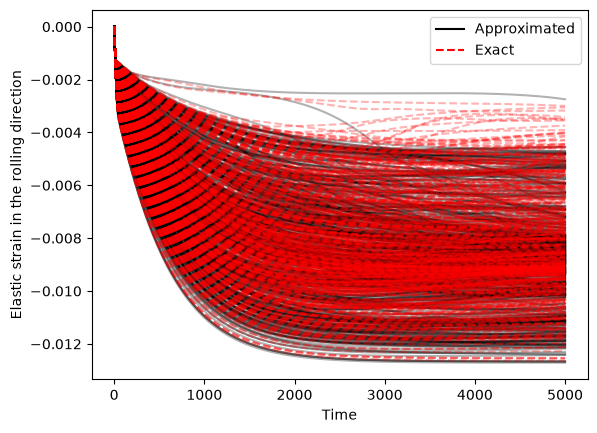

In [11]:
# Elastic strain in the rolling direction (zz), every crystal.
plt.plot(t_axis, elastic_strain_approx.data[:, :, 2].cpu(), "k-", alpha=0.3)
plt.plot(t_axis, E_exact[:, :, 2, 2].cpu(), "r--", alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Elastic strain in the rolling direction")
plt.legend(
    [Line2D([0], [0], color="k"), Line2D([0], [0], color="r", linestyle="--")],
    ["Approximated", "Exact"],
    loc="best",
)
plt.show()

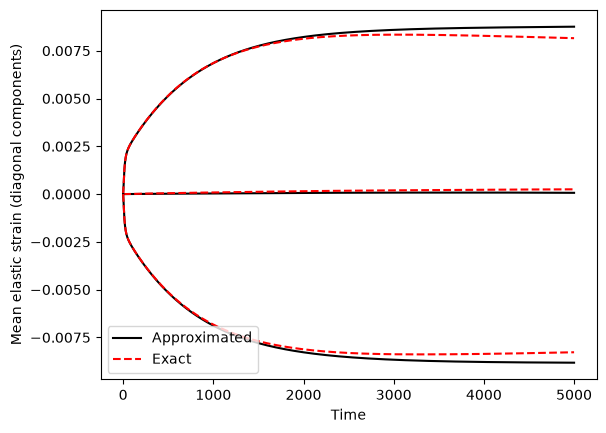

In [12]:
# Averages of the diagonal elastic strain components.
for i in range(3):
    plt.plot(t_axis, elastic_strain_approx.data[:, :, i].mean(dim=-1).cpu(), "k-")
    plt.plot(t_axis, E_exact[:, :, i, i].mean(dim=-1).cpu(), "r--")
plt.xlabel("Time")
plt.ylabel("Mean elastic strain (diagonal components)")
plt.legend(
    [Line2D([0], [0], color="k"), Line2D([0], [0], color="r", linestyle="--")],
    ["Approximated", "Exact"],
    loc="best",
)
plt.show()